In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import seaborn as sns
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.rdm import RDMs
from glob import glob
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

In [3]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [4]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

## 0. Load data

In [5]:
image_path = '../IAPS_fMRI_RSA/fMRI/nifti/Nt1.img'


# load one image to get the dimensions and make the mask
tmp_img = nib.load(image_path)
# we infer the mask by looking at non-nan voxels
mask = ~np.isnan(tmp_img.get_fdata())
x, y, z = tmp_img.get_fdata().shape

In [6]:
tmp_img.get_fdata().shape

(53, 63, 46)

### Stimuli

In [6]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
stim_Nt = stim_file[0:100]
stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [7]:
stim_Up

,index,trial_id,iaps_id,run,type,stim_order,category,Mean_Valence,Mean_Arousal
0,200,4,3030,1,Up,1,mutil/disgust,1.91,6.76
1,201,5,3051,1,Up,2,mutil/disgust,2.30,5.62
2,202,11,1120,1,Up,3,attack,3.79,6.93
3,203,12,6550,1,Up,4,attack,2.73,7.09
4,204,13,3150,1,Up,5,mutil/disgust,2.26,6.55
...,...,...,...,...,...,...,...,...,...
95,295,295,6230,5,Up,15,attack,2.37,7.35
96,296,297,9571,5,Up,16,mutil/disgust,1.96,5.64
97,297,298,3069,5,Up,9,mutil/disgust,1.70,7.03
98,298,299,1114,5,Up,8,attack,4.03,6.33


In [8]:
stim_Nt_id = pd.DataFrame(stim_Nt[['stim_order']]).T
stim_Nt_id.shape
stim_Pl_id = pd.DataFrame(stim_Pl[['stim_order']]).T
stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['stim_order']]).T
stim_Up_id.shape
print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [10]:
stim_Pl_id

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
stim_order,1,2,3,4,5,6,7,8,9,10,...,3,9,1,19,15,13,14,4,20,10


In [9]:
sub_avg = []

subjects = 20
for i in range(subjects):
    cond_all = []
    cond_avg = []
    #Pleasant
    mat_name_Pl = '../IAPS_fMRI_RSA/fMRI/Pl{}.mat'.format(i+1)
    mat_file_Pl = sio.loadmat(mat_name_Pl)
    data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    data_Pl_df = pd.DataFrame(data_Pl) #(153594, 100)
    stim_Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    stim_Pl_df2 = stim_Pl_df.T #(100, 153595)
    stim_Pl_df3 = stim_Pl_df2.groupby('stim_order').mean() #(20, 153594) 
    Pl_avg = stim_Pl_df3.reset_index(drop=True) #(20, 153594)
    cond_avg.append(Pl_avg)
    #Neutral
    mat_name_Nt = '../IAPS_fMRI_RSA/fMRI/Nt{}.mat'.format(i+1)
    mat_file_Nt = sio.loadmat(mat_name_Nt)
    data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    data_Nt_df = pd.DataFrame(data_Nt) #(153594, 100)
    stim_Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    stim_Nt_df2 = stim_Nt_df.T #(100, 153595)
    stim_Nt_df3 = stim_Nt_df2.groupby('stim_order').mean() #(20, 153594)
    Nt_avg = stim_Nt_df3.reset_index(drop=True) #(20, 153594)
    cond_avg.append(Nt_avg)
    #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_df = pd.DataFrame(data_Up) #(153594, 100)
    stim_Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    stim_Up_df2 = stim_Up_df.T #(100, 153595)
    stim_Up_df3 = stim_Up_df2.groupby('stim_order').mean() #(20, 153594)
    Up_avg = stim_Up_df3.reset_index(drop=True) #(20, 153594)
    cond_avg.append(Up_avg)

    subj_avg_arr = np.vstack(cond_avg)
    subj_avg_df = pd.DataFrame(subj_avg_arr)
    sub_avg.append(subj_avg_df)

In [12]:
print("Type: {}, Length: {}, Shape: {}".format(type(sub_avg), len(sub_avg), sub_avg[0].shape))

Type: <class 'list'>, Length: 20, Shape: (60, 153594)


In [10]:
subj_data = sub_avg[1]
subj_data.shape

(60, 153594)

## 1. Get searchlight centers and neighbors

In this example we allow neighboring voxels to be 5 voxels away from the central voxel. In order for it to be a proper center at least 50% of the neighboring voxels needs to be within the brain mask (threshold=0.5)

In [11]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 64544/64544 [00:27<00:00, 2314.26it/s]


Found 61997 searchlights


## 2. Get an RDM for each voxel

In [12]:
subj_data_2d = np.nan_to_num(subj_data)

In [13]:
image_value = np.arange(60)
image_value 

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59])

In [14]:
# Get RDMs
SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

Calculating RDMs...: 100%|██████████| 100/100 [05:00<00:00,  3.00s/it]


## 3. Load stimuli model and evaluate

Now, we need to create stilumi RDMs i.e.60x60.

In [15]:
erotic_flag = pd.read_csv("./erotic_flag.csv", header = None)
erotic_flag = np.array(erotic_flag)
erotic_flag.shape
erotic_model = ModelFixed('Erotic RDM', upper_tri(erotic_flag))

In [16]:

eval_results = evaluate_models_searchlight(SL_RDM, erotic_model, eval_fixed, method='spearman', n_jobs=3)

# get the evaulation score for each voxel
# We only have one model, but evaluations returns a list. By using float we just grab the value within that list
eval_score = [np.float(e.evaluations) for e in eval_results]
# Create an 3D array, with the size of mask, and
x, y, z = mask.shape
RDM_brain = np.zeros([x*y*z])
RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
RDM_brain = RDM_brain.reshape([x, y, z])

Evaluating models for each searchlight: 100%|██████████| 61997/61997 [01:31<00:00, 679.11it/s] 
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11160\2839897652.py:5: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eval_score = [np.float(e.evaluations) for e in eval_results]


## 4. Plot results

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11160\888380278.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(eval_score)


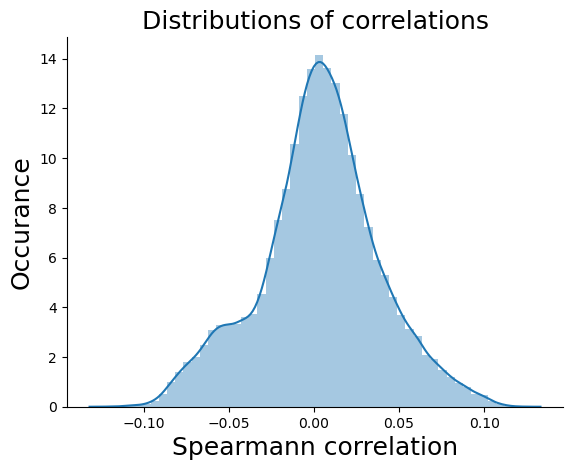

In [17]:
sns.distplot(eval_score)
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

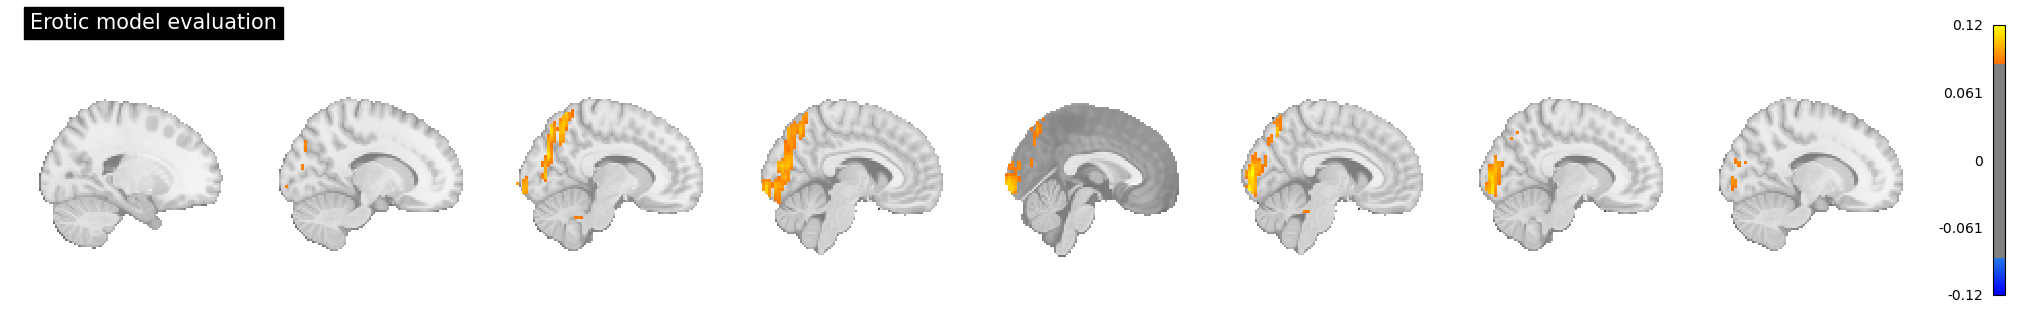

In [24]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score, 99)
plot_img = new_img_like(tmp_img, RDM_brain)

cmap = RDMcolormapObject()

coords = range(-20, 20, 5)
fig = plt.figure(figsize=(20, 3))

display = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='x', draw_cross=False, figure=fig,
        title=f'Erotic model evaluation', cmap=cmap,
        black_bg=False, annotate=False)
plt.show()

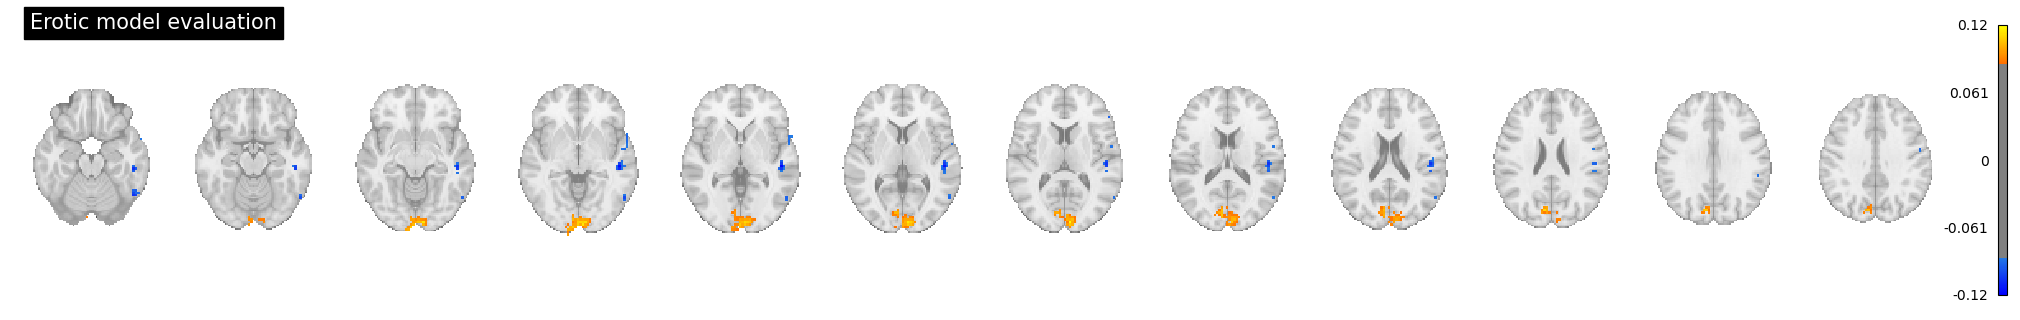

In [25]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score, 99)
plot_img = new_img_like(tmp_img, RDM_brain)

cmap = RDMcolormapObject()

coords = range(-20, 40, 5)
fig = plt.figure(figsize=(20, 3))

display = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='z', draw_cross=False, figure=fig,
        title=f'Erotic model evaluation', cmap=cmap,
        black_bg=False, annotate=False)
plt.show()

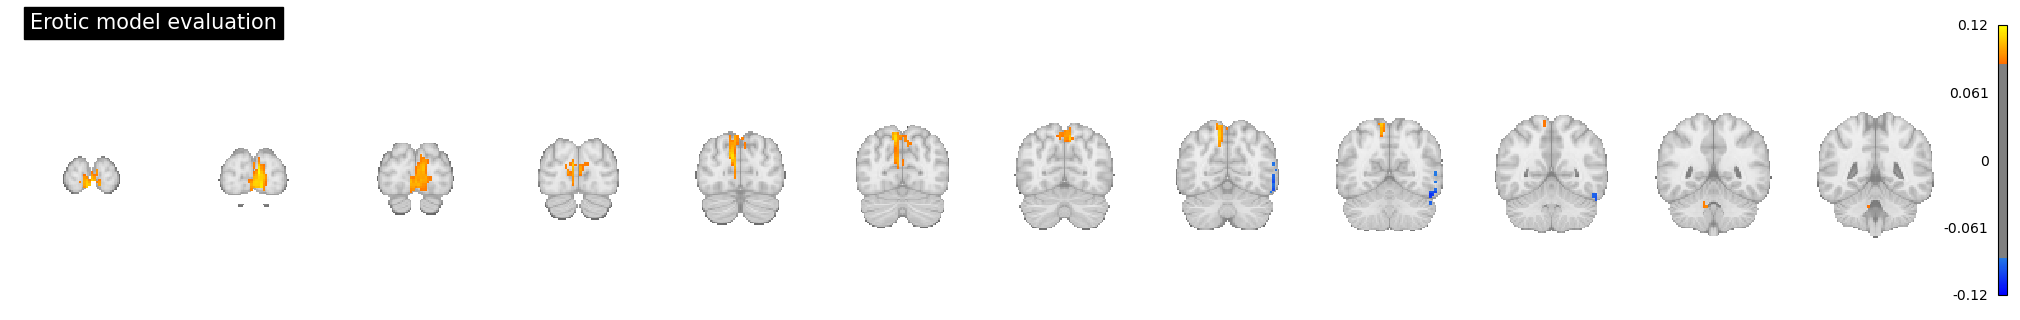

In [23]:
# lets plot the voxels above the 99th percentile
threshold = np.percentile(eval_score, 99)
plot_img = new_img_like(tmp_img, RDM_brain)

cmap = RDMcolormapObject()

coords = range(-100, -40, 5)
fig = plt.figure(figsize=(20, 3))

display = plotting.plot_stat_map(
        plot_img, colorbar=True, cut_coords=coords,threshold=threshold,
        display_mode='y', draw_cross=False, figure=fig,
        title=f'Erotic model evaluation', cmap=cmap,
        black_bg=False, annotate=False)
plt.show()